# Predicting Australian Used Car Prices

**Author:** Alexander Montague  
**Completed:** 1/07/2026  
**Data period:** 2023  
**Data source:** Used car listings collected from multiple online automotive marketplaces across Australia

## Project Objective
This project investigates whether vehicle and listing characteristics can be used to estimate the price of used cars in Australia. The project includes data cleaning, exploratory data analysis, feature engineering, regression model development, model comparison, and evaluation. The modelling work also exports a clean modelling dataset and split metadata that are used by the dashboard interval model and interactive price-estimation app.


## 1. Import Packages

Import the core data science, visualisation, preprocessing, modelling, and evaluation packages used throughout the project.

In [29]:
# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Model selection
from sklearn.model_selection import (
    train_test_split,
    cross_validate
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin

# Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score
)

# Export
from pathlib import Path
import json

# Project paths
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODEL_INPUT_DIR = DATA_DIR / "model_inputs"

# Display
from IPython.display import Markdown

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 2. Load and Inspect Data
Load the Australian vehicle price dataset and inspect its structure, data types, missing values, and first few records.

In [30]:
# Load dataset
df = pd.read_csv(DATA_DIR / "australian_vehicle_prices_2023.csv")

# Preview first few rows
display(Markdown("### First five rows"))
display(df.head())

# Inspect column names, data types, and non-null counts
display(Markdown("### Dataset information"))
df.info()

# Check dataset size
display(Markdown("### Dataset shape"))
display(df.shape)

# Summary statistics for numeric columns
print("\nSummary statistics:")
display(df.describe())

# Inspect unique categorical column values and counts
display(Markdown("### Categorical variables"))
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_summary = pd.DataFrame({
    "Unique values": [df[col].nunique(dropna=False) for col in categorical_cols]
}, index=categorical_cols)
display(categorical_summary.sort_values("Unique values", ascending=False))

# Inspect columns with the most missing values
display(Markdown("### Top 5 columns by missing values"))
display(df.isna().sum().sort_values(ascending=False).head(5))


### First five rows

,Brand,Year,Model,Car/Suv,Title,UsedOrNew,Transmission,Engine,DriveType,FuelType,FuelConsumption,Kilometres,ColourExtInt,Location,CylindersinEngine,BodyType,Doors,Seats,Price
0,Ssangyong,2022.000,Rexton,Sutherland Isuzu Ute,2022 Ssangyong Rexton Ultimate (awd),DEMO,Automatic,"4 cyl, 2.2 L",AWD,Diesel,8.7 L / 100 km,5595,White / Black,"Caringbah, NSW",4 cyl,SUV,4 Doors,7 Seats,51990
1,MG,2022.000,MG3,Hatchback,2022 MG MG3 Auto Excite (with Navigation),USED,Automatic,"4 cyl, 1.5 L",Front,Premium,6.7 L / 100 km,16,Black / Black,"Brookvale, NSW",4 cyl,Hatchback,5 Doors,5 Seats,19990
2,BMW,2022.000,430I,Coupe,2022 BMW 430I M Sport,USED,Automatic,"4 cyl, 2 L",Rear,Premium,6.6 L / 100 km,8472,Grey / White,"Sylvania, NSW",4 cyl,Coupe,2 Doors,4 Seats,108988
3,Mercedes-Benz,2011.000,E500,Coupe,2011 Mercedes-Benz E500 Elegance,USED,Automatic,"8 cyl, 5.5 L",Rear,Premium,11 L / 100 km,136517,White / Brown,"Mount Druitt, NSW",8 cyl,Coupe,2 Doors,4 Seats,32990
4,Renault,2022.000,Arkana,SUV,2022 Renault Arkana Intens,USED,Automatic,"4 cyl, 1.3 L",Front,Unleaded,6 L / 100 km,1035,Grey / Black,"Castle Hill, NSW",4 cyl,SUV,4 Doors,5 Seats,34990


### Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16734 entries, 0 to 16733
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              16733 non-null  object 
 1   Year               16733 non-null  float64
 2   Model              16733 non-null  object 
 3   Car/Suv            16706 non-null  object 
 4   Title              16733 non-null  object 
 5   UsedOrNew          16733 non-null  object 
 6   Transmission       16733 non-null  object 
 7   Engine             16733 non-null  object 
 8   DriveType          16733 non-null  object 
 9   FuelType           16733 non-null  object 
 10  FuelConsumption    16733 non-null  object 
 11  Kilometres         16733 non-null  object 
 12  ColourExtInt       16733 non-null  object 
 13  Location           16284 non-null  object 
 14  CylindersinEngine  16733 non-null  object 
 15  BodyType           16452 non-null  object 
 16  Doors              151

### Dataset shape

...

,Year
count,16733.000
mean,2016.229
std,5.248
min,1940.000
25%,2013.000
50%,2017.000
75%,2020.000
max,2023.000


### Categorical variables

,Unique values
Kilometres,14263
Title,8805
Price,3795
ColourExtInt,835
Model,782
Location,619
Car/Suv,619
FuelConsumption,158
Engine,107
Brand,77


### Top 5 columns by missing values

Seats       1705
Doors       1604
Location     450
BodyType     282
Car/Suv       28
dtype: int64

Initial inspection shows that the dataset contains 16,734 vehicle listings across 19 variables. Most columns have been loaded as `object` data types, despite several appearing to represent numerical information.

Variables such as **Price**, **Kilometres**, **Doors**, **Seats**, **CylindersinEngine**, and **FuelConsumption** contain numerical values stored alongside descriptive text (e.g., "4 Doors", "5 Seats", "6 cyl", or "8.1 L / 100 km"), causing them to be interpreted as categorical variables. Similarly, the **Engine** column combines cylinder count and engine size information within a single field, despite cylinder count already being provided separately. These variables will require cleaning and conversion before analysis and modelling can be performed.

The categorical variable summary also highlights several high-cardinality variables, particularly **Kilometres**, **Title**, **Price**, **Model**, and **Location**, which contain a large number of unique values. Further investigation will be required to determine the most appropriate preprocessing approach for these variables.

Initial inspection of missing values indicates that **Seats** and **Doors** contain the largest number of missing observations, while **Location** and **BodyType** also contain some missing data. The extent and treatment of missing values will be investigated further during the data cleaning stage.

## 3. Data Cleaning and Feature Preparation

In [31]:
# Create a working copy for cleaning
df_clean = df.copy()

# Rename columns to consistent snake_case names
df_clean = df_clean.rename(columns={
    "Brand": "brand",
    "Year": "year",
    "Model": "model",
    "Car/Suv": "car_suv",
    "Title": "title",
    "UsedOrNew": "used_or_new",
    "Transmission": "transmission",
    "Engine": "engine_size_litres",
    "DriveType": "drive_type",
    "FuelType": "fuel_type",
    "FuelConsumption": "fuel_consumption_per_100km",
    "Kilometres": "kilometres",
    "ColourExtInt": "colour_ext_int",
    "Location": "location",
    "CylindersinEngine": "cylinders",
    "BodyType": "body_type",
    "Doors": "doors",
    "Seats": "seats",
    "Price": "price"
})

# Drop car_suv because body_type contains the cleaner vehicle body category
df_clean = df_clean.drop(columns="car_suv")

# Split exterior and interior colour into separate columns
df_clean[["colour_ext", "colour_int"]] = (
    df_clean["colour_ext_int"]
    .astype("string")
    .str.split(" / ", n=1, expand=True)
)

df_clean = df_clean.drop(columns="colour_ext_int")

# Split location into region and state columns
location_split = df_clean["location"].astype("string").str.split(",", n=1, expand=True)
df_clean["region"] = location_split[0].str.strip()
df_clean["state"] = location_split[1].str.strip()
df_clean["state"] = df_clean["state"].replace({"AU-VIC": "VIC"})

df_clean = df_clean.drop(columns="location")

# Replace categorical placeholder values with missing values
categorical_placeholder_cols = ["transmission", "fuel_type", "colour_ext", "colour_int"]

for col in categorical_placeholder_cols:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
        .replace({"-": np.nan})
    )

# Inspect listing condition counts, then retain only used vehicles
display(Markdown("### Listing condition counts"))
display(df_clean["used_or_new"].value_counts(dropna=False))

df_clean = df_clean[df_clean["used_or_new"] == "USED"].copy()

# Convert year, price, and kilometres from text/object fields to numeric values
numeric_text_cols = ["year", "price", "kilometres"]

for col in numeric_text_cols:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.replace(",", "", regex=False)
        .replace({"POA": np.nan, "-": np.nan, "- / -": np.nan})
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").astype("Int64")

# Remove rows where the target variable is missing
df_clean = df_clean.dropna(subset=["price"]).copy()

# Extract engine size and fuel consumption values, then convert to floats
float_text_cols = ["engine_size_litres", "fuel_consumption_per_100km"]

for col in float_text_cols:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.extract(r"(\d+(?:\.\d+)?)\s*L", expand=False)
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Remove text labels from count columns, then convert to integer values
count_text_cols = {
    "cylinders": r"(?i)\s*(cyl|L)",
    "doors": r"(?i)\s*Doors?",
    "seats": r"(?i)\s*Seats?"
}

for col, text_pattern in count_text_cols.items():
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.replace(text_pattern, "", regex=True)
        .str.strip()
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").astype("Int64")

# Engineer vehicle age and average kilometres per year
df_clean["vehicle_age"] = (2023 - df_clean["year"]).astype("Int64")
vehicle_age_for_rate = df_clean["vehicle_age"].replace(0, 1)
df_clean["km_per_year"] = (df_clean["kilometres"] / vehicle_age_for_rate).astype("Float64")

# Reset the index after filtering rows
df_clean = df_clean.reset_index(drop=True)

engineered_numeric_cols = ["vehicle_age", "km_per_year"]
converted_numeric_cols = numeric_text_cols + float_text_cols + list(count_text_cols.keys()) + engineered_numeric_cols

# Confirm the converted data types and summary statistics
display(Markdown("### Converted numeric columns"))
display(df_clean[converted_numeric_cols].dtypes.to_frame("Data type"))

display(Markdown("### Summary statistics"))
display(df_clean[converted_numeric_cols].describe())

# Remove implausibly low price anomaly identified in the summary statistics
df_clean = df_clean[df_clean["price"] != 88].reset_index(drop=True)

display(Markdown("### First five rows of cleaned dataset"))
display(df_clean.head())

display(Markdown("### Cleaned dataset shape"))
display(df_clean.shape)

display(Markdown("### Top 5 columns by missing values after initial cleaning"))
display(df_clean.isna().sum().sort_values(ascending=False).head(5).to_frame("Missing values"))


### Listing condition counts

used_or_new
USED    14994
NEW      1227
DEMO      512
NaN         1
Name: count, dtype: int64

### Converted numeric columns

,Data type
year,Int64
price,Int64
kilometres,Int64
engine_size_litres,Float64
fuel_consumption_per_100km,Float64
cylinders,Int64
doors,Int64
seats,Int64
vehicle_age,Int64
km_per_year,Float64


### Summary statistics

...

,brand,year,model,title,used_or_new,transmission,engine_size_litres,drive_type,fuel_type,fuel_consumption_per_100km,kilometres,cylinders,body_type,doors,seats,price,colour_ext,colour_int,region,state,vehicle_age,km_per_year
0,MG,2022,MG3,2022 MG MG3 Auto Excite (with Navigation),USED,Automatic,1.500,Front,Premium,6.700,16,4,Hatchback,5,5,19990,Black,Black,Brookvale,NSW,1,16.000
1,BMW,2022,430I,2022 BMW 430I M Sport,USED,Automatic,2.000,Rear,Premium,6.600,8472,4,Coupe,2,4,108988,Grey,White,Sylvania,NSW,1,8472.000
2,Mercedes-Benz,2011,E500,2011 Mercedes-Benz E500 Elegance,USED,Automatic,5.500,Rear,Premium,11.000,136517,8,Coupe,2,4,32990,White,Brown,Mount Druitt,NSW,12,11376.417
3,Renault,2022,Arkana,2022 Renault Arkana Intens,USED,Automatic,1.300,Front,Unleaded,6.000,1035,4,SUV,4,5,34990,Grey,Black,Castle Hill,NSW,1,1035.000
4,Toyota,2004,Estima,2004 Toyota Estima T EDITION,USED,Automatic,<NA>,Other,Unleaded,<NA>,160230,<NA>,Commercial,<NA>,<NA>,9990,Grey,<NA>,Saint Marys,NSW,19,8433.158


### Cleaned dataset shape

(14983, 22)

### Top 5 columns by missing values after initial cleaning

,Missing values
colour_int,7230
fuel_consumption_per_100km,1472
seats,1472
engine_size_litres,1449
cylinders,1449


The data cleaning and feature preparation stage created a working copy of the original dataset, renamed the columns to consistent `snake_case`, and removed the `car_suv` column because `body_type` provides a cleaner vehicle category. The combined exterior/interior colour field was split into separate `colour_ext` and `colour_int` columns, while `location` was split into `region` and `state` to make geographic information easier to analyse and model. Placeholder values recorded as `-` were converted to missing values for selected categorical variables, and the inconsistent state value `AU-VIC` was standardised to `VIC`. The dataset was then restricted to `USED` listings only, as the aim of this project is to predict used car prices and new/demo vehicles may follow different pricing patterns. Several text-based numerical fields were converted into model-ready numeric variables: `year`, `price`, and `kilometres` were converted to integers, `engine_size_litres` and `fuel_consumption_per_100km` were extracted as floats, and `cylinders`, `doors`, and `seats` were converted to integer count variables. Rows with missing `price` values were removed because `price` is the target variable and supervised learning models require a known response value for training. The summary statistics also showed one unusually low listing priced at $88, which is far below the next cheapest vehicles and is likely to represent a listing error, placeholder price, or otherwise non-representative observation. This value was removed from the cleaned dataset so that later percentage-based modelling metrics are not distorted by an implausibly small target value. Two additional features were engineered: `vehicle_age`, calculated as `2023 - year`, and `km_per_year`, calculated as kilometres divided by vehicle age. For vehicles listed with a 2023 model year, vehicle age was treated as one year in the `km_per_year` calculation to avoid division by zero and preserve the information contained in the odometer reading. Although `colour_int` was retained for exploratory analysis, it contains a large number of missing values and inconsistent interior colour, material, and trim labels. For this reason, the raw `colour_int` field will not be included in the modelling feature set unless it is cleaned or grouped more carefully in future work. Some missing values remain in the predictor variables after cleaning, which is expected and will be handled during the model preparation stage using appropriate preprocessing techniques such as imputation.

## 4. Exploratory Data Analysis

The purpose of this section is to explore the structure of the cleaned used-car dataset and identify potential relationships between the predictor variables and the target variable, `price`.

The analysis will focus on:
- Understanding the distribution of vehicle characteristic variables.
- Examining the distribution of used-car prices.
- Investigating how price varies across vehicle age, kilometres, brand, body type, fuel type, and location-based features.
- Identifying potentially important predictors for the modelling stage.
- Detecting any unusual observations or data quality issues that may influence model performance.

Insights from this analysis will be used to guide feature selection and modelling decisions in the predictive modelling section.

### 4.1 Distribution of Used-Car Prices

The first step in the exploratory analysis is to examine the distribution of the target variable, `price`. Understanding the spread, skewness, and potential extreme values in used-car prices is important because the target distribution can influence model performance and may inform later modelling decisions. Since used-car prices can contain a small number of very high-value listings, the histogram below focuses on the main market range up to the 99th percentile.

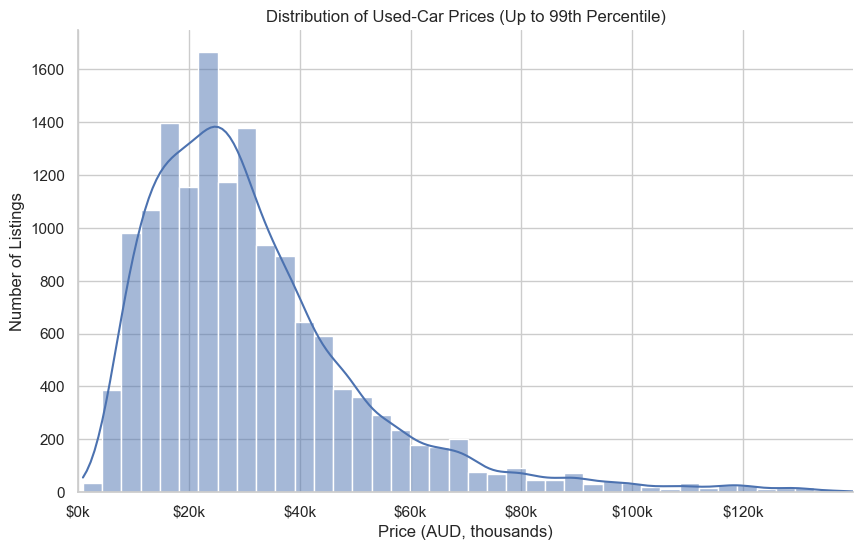

In [32]:
# Plot the distribution of used-car prices
eda_price_upper = df_clean["price"].quantile(0.99)
df_eda_main_market = df_clean[df_clean["price"] <= eda_price_upper].copy()

plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df_eda_main_market, x="price", bins=40, kde=True)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x / 1000:.0f}k"))
plt.title("Distribution of Used-Car Prices (Up to 99th Percentile)")
plt.xlabel("Price (AUD, thousands)")
plt.ylabel("Number of Listings")
plt.xlim(0, eda_price_upper)
sns.despine()
plt.show()


In [33]:
# Inspect the most and least expensive used-car listings
top_price_listings = (
    df_clean
    .sort_values("price", ascending=False)
    [["brand", "model", "title", "year", "vehicle_age", "kilometres", "body_type", "state", "price"]]
    .head(5)
)

bottom_price_listings = (
    df_clean
    .sort_values("price", ascending=True)
    [["brand", "model", "title", "year", "vehicle_age", "kilometres", "body_type", "state", "price"]]
    .head(5)
)

display(Markdown("### Top 5 most expensive used-car listings"))
display(top_price_listings)

display(Markdown("### Top 5 least expensive used-car listings"))
display(bottom_price_listings)


### Top 5 most expensive used-car listings

,brand,model,title,year,vehicle_age,kilometres,body_type,state,price
13977,Ferrari,250,1959 Ferrari 250 Pininfarina,1959,64,9902,Coupe,NSW,1500000
9752,Lamborghini,Aventador,2012 Lamborghini Aventador,2012,11,27843,Coupe,VIC,649880
3178,McLaren,720S,2019 McLaren 720S Spider Luxury,2019,4,138,Convertible,NSW,649880
4949,Ferrari,GTC4,2019 Ferrari GTC4 Lusso (awd),2019,4,11480,Coupe,NSW,579888
3601,Mercedes-Benz,G63,2023 Mercedes-Benz G63 EDITION 55,2023,0,205,Wagon,NSW,499990


### Top 5 least expensive used-car listings

,brand,model,title,year,vehicle_age,kilometres,body_type,state,price
11610,Daewoo,Lanos,1998 Daewoo Lanos SE,1998,25,310000,Sedan,QLD,900
12299,Mazda,6,2004 Mazda 6 Luxury Sports,2004,19,201123,Hatchback,QLD,1200
1696,Chrysler,Sebring,2008 Chrysler Sebring Limited,2008,15,129863,Sedan,NSW,1895
4571,Mercedes-Benz,MB100,2002 Mercedes-Benz MB100 D (2.9),2002,21,460269,Commercial,NSW,1895
7379,Volkswagen,Passat,2003 Volkswagen Passat SE,2003,20,257234,NaN,VIC,2050


The distribution of `price` is strongly right-skewed, with most used-car listings concentrated at lower price ranges and a small number of very high-value vehicles extending the upper tail. For readability, the histogram focuses on prices up to the 99th percentile, while the table of the five most expensive listings confirms that the upper tail is largely made up of exotic, prestige, or unusually high-value vehicles. These listings are still valid used-car observations, but they are not representative of the intended use case: predicting prices for typical vehicles entered by an average user. For this reason, the modelling stage will focus on main-market listings up to the 99th percentile of price, rather than allowing rare high-price listings to disproportionately influence model training and evaluation. Even after focusing on the main-market range, the target remains right-skewed, suggesting that a log transformation may provide a more balanced response variable for modelling.

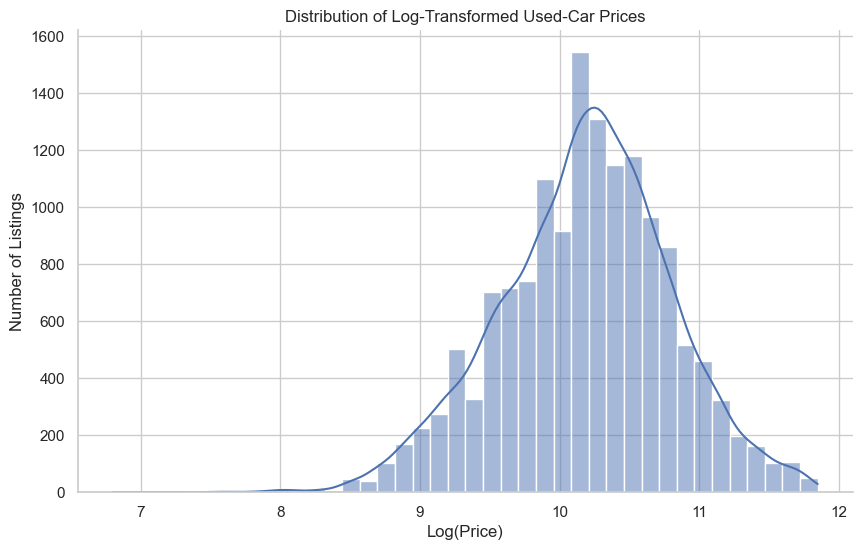

In [34]:
# Plot the distribution of log-transformed used-car prices
log_price = np.log1p(df_eda_main_market["price"])

plt.figure(figsize=(10, 6))
sns.histplot(log_price, bins=40, kde=True)
plt.title("Distribution of Log-Transformed Used-Car Prices")
plt.xlabel("Log(Price)")
plt.ylabel("Number of Listings")
sns.despine()
plt.show()


The log transformation compresses the long right tail of the price distribution and produces a more balanced target variable. This is useful for modelling because the algorithms can focus more on proportional price differences rather than being dominated by the largest absolute dollar values.

### 4.2 Relationships Between Numeric Variables and Price

This section examines how the main numerical vehicle characteristics relate to `price`. Scatterplots are used for variables that have a relatively continuous range of values, including vehicle age, kilometres, average kilometres per year, engine size, and fuel consumption. Since the extreme upper-tail prices were identified in the previous section, these plots focus on the main used-car market up to the 99th percentile so that the broader relationships are easier to interpret.

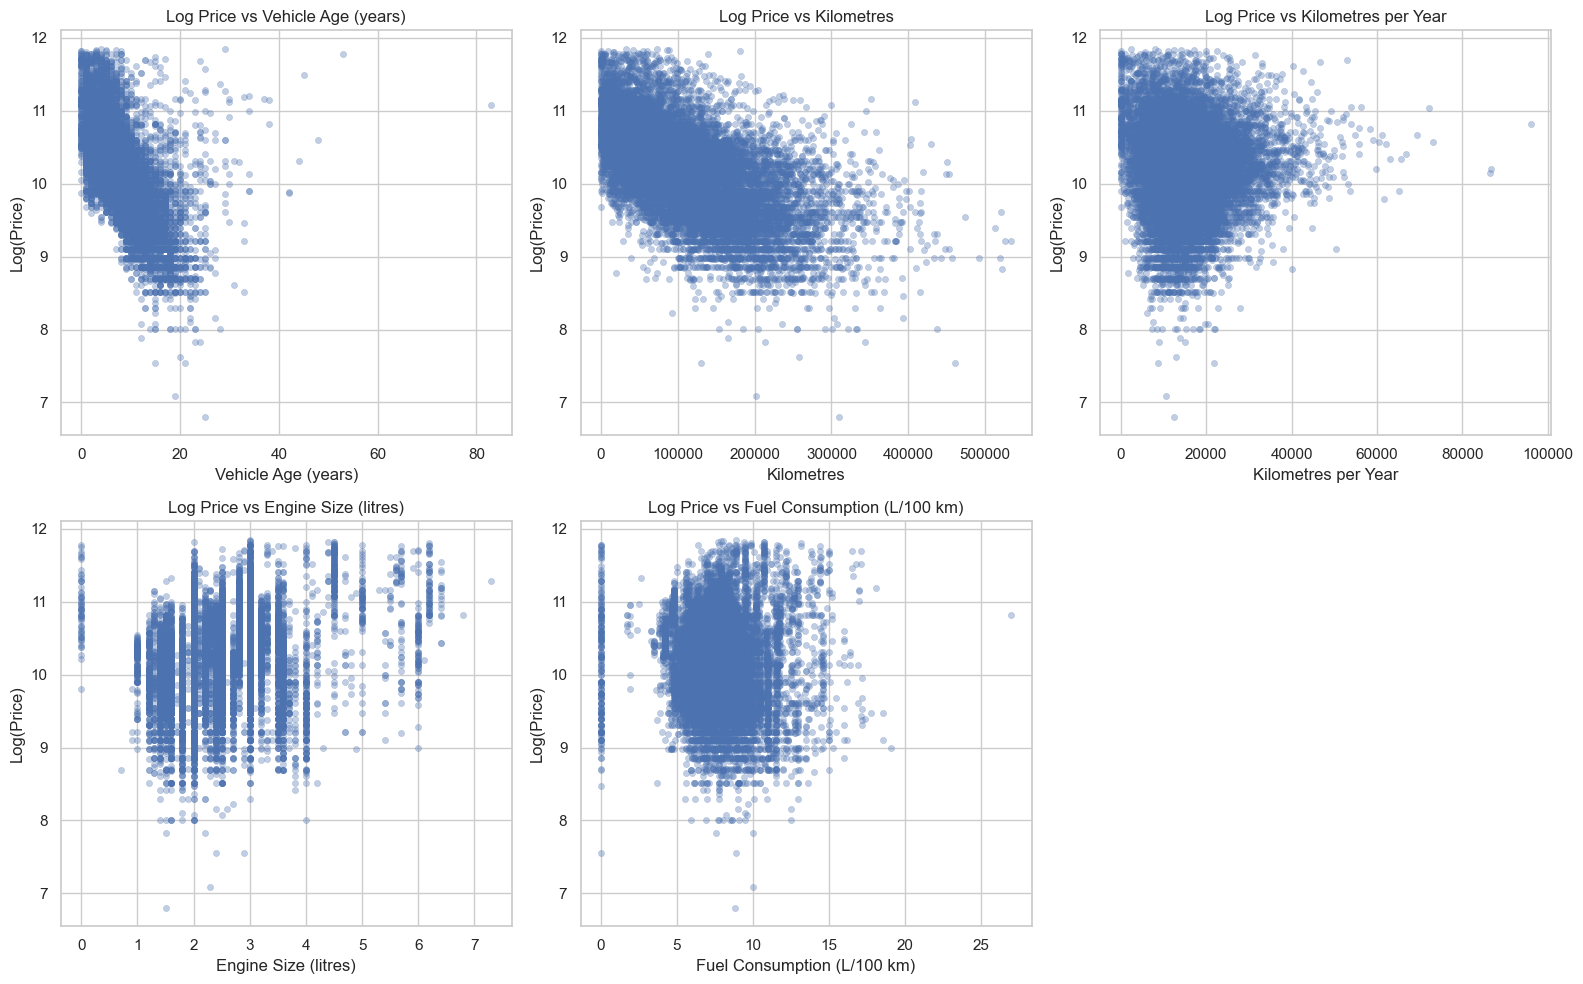

In [35]:
# Plot relationships between continuous numeric predictors and log-transformed price
numeric_scatter_cols = {
    "vehicle_age": "Vehicle Age (years)",
    "kilometres": "Kilometres",
    "km_per_year": "Kilometres per Year",
    "engine_size_litres": "Engine Size (litres)",
    "fuel_consumption_per_100km": "Fuel Consumption (L/100 km)"
}

numeric_scatter_data = df_eda_main_market.assign(log_price=np.log1p(df_eda_main_market["price"]))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (col, label) in zip(axes, numeric_scatter_cols.items()):
    sns.scatterplot(
        data=numeric_scatter_data,
        x=col,
        y="log_price",
        alpha=0.35,
        s=20,
        edgecolor=None,
        ax=ax
    )
    ax.set_title(f"Log Price vs {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Log(Price)")

for ax in axes[len(numeric_scatter_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


The clearest relationships appear to be between `price` and both `vehicle_age` and `kilometres`, with newer vehicles and vehicles with lower odometer readings generally listed at higher prices. The relationship between `km_per_year` and `price` is less clear, which is expected because this feature combines both age and usage; in some cases total kilometres may be more important, while in others the age of the vehicle may matter more. There is also some indication that vehicles with larger engine sizes can command higher prices, although the relationship is not especially clean and likely interacts with brand, body type, and vehicle segment. Fuel consumption shows the weakest and noisiest relationship with price in these plots. The zero values visible for fuel consumption, engine size, and cylinders may reflect electric vehicles in some cases, but could also indicate data quality issues where non-electric vehicles have been recorded with impossible zero values. These values are therefore recognised as a data quality limitation during modelling and interpretation.

For count-based numeric variables such as `cylinders`, `doors`, and `seats`, boxplots are more useful than scatterplots because these variables have a small number of repeated integer values. The plots below compare the distribution of prices across each count category.

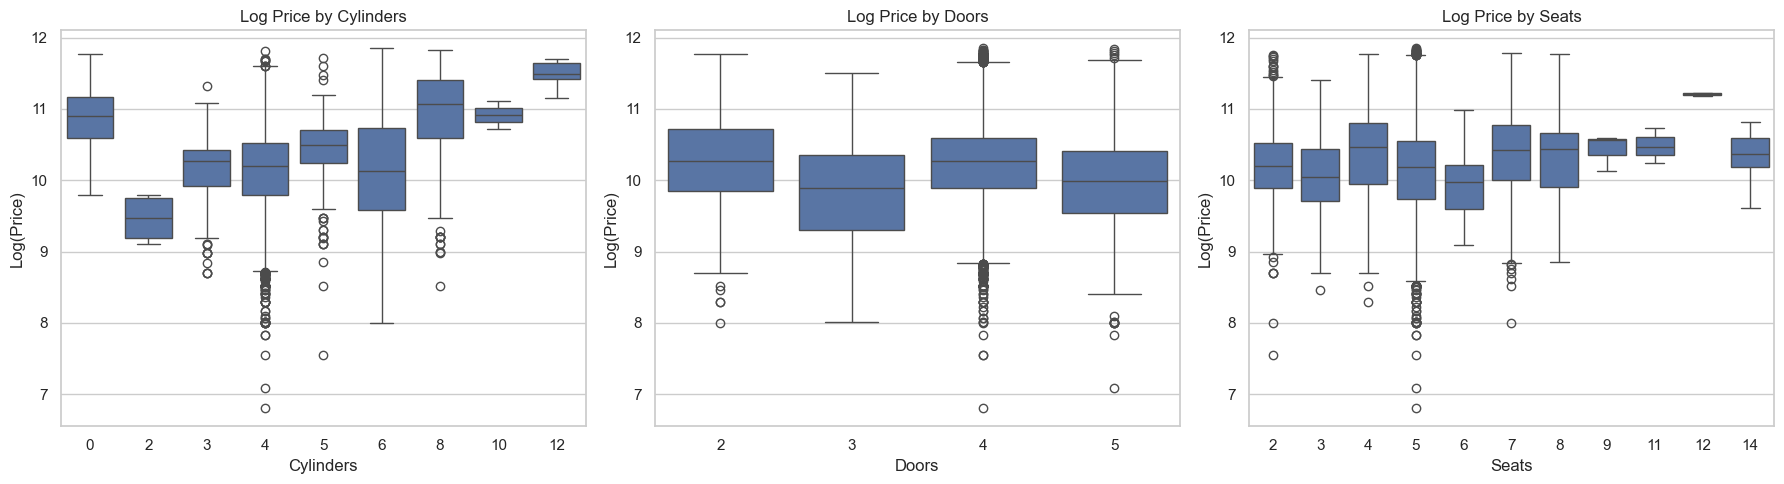

In [36]:
# Plot log-price distributions across count-based numeric variables
count_price_cols = {
    "cylinders": "Cylinders",
    "doors": "Doors",
    "seats": "Seats"
}

count_price_data = df_eda_main_market.assign(log_price=np.log1p(df_eda_main_market["price"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label) in zip(axes, count_price_cols.items()):
    sns.boxplot(
        data=count_price_data,
        x=col,
        y="log_price",
        ax=ax
    )
    ax.set_title(f"Log Price by {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Log(Price)")

plt.tight_layout()
plt.show()


Among the count-based variables, `cylinders` appears to show the clearest relationship with `price`. Vehicles with zero cylinders generally have relatively high prices, which is likely because these observations represent electric vehicles, while prices also tend to increase across higher cylinder counts after the very small-cylinder categories. However, the spread for some groups, particularly 6- and 8-cylinder vehicles, is wide, suggesting that cylinder count alone does not fully explain price differences. The relationships for `doors` and `seats` are weaker and less consistent. Door count appears to provide limited separation between price groups, while seat count may partly reflect vehicle segment rather than a simple linear pricing effect. These variables may still be useful in modelling, but their influence is likely to depend on interactions with other features such as body type, brand, and vehicle category.

A correlation heatmap is used to summarise the linear relationships between the numeric predictors and `price`. This also helps identify predictors that may contain overlapping information, such as `vehicle_age`, `kilometres`, and `km_per_year`.

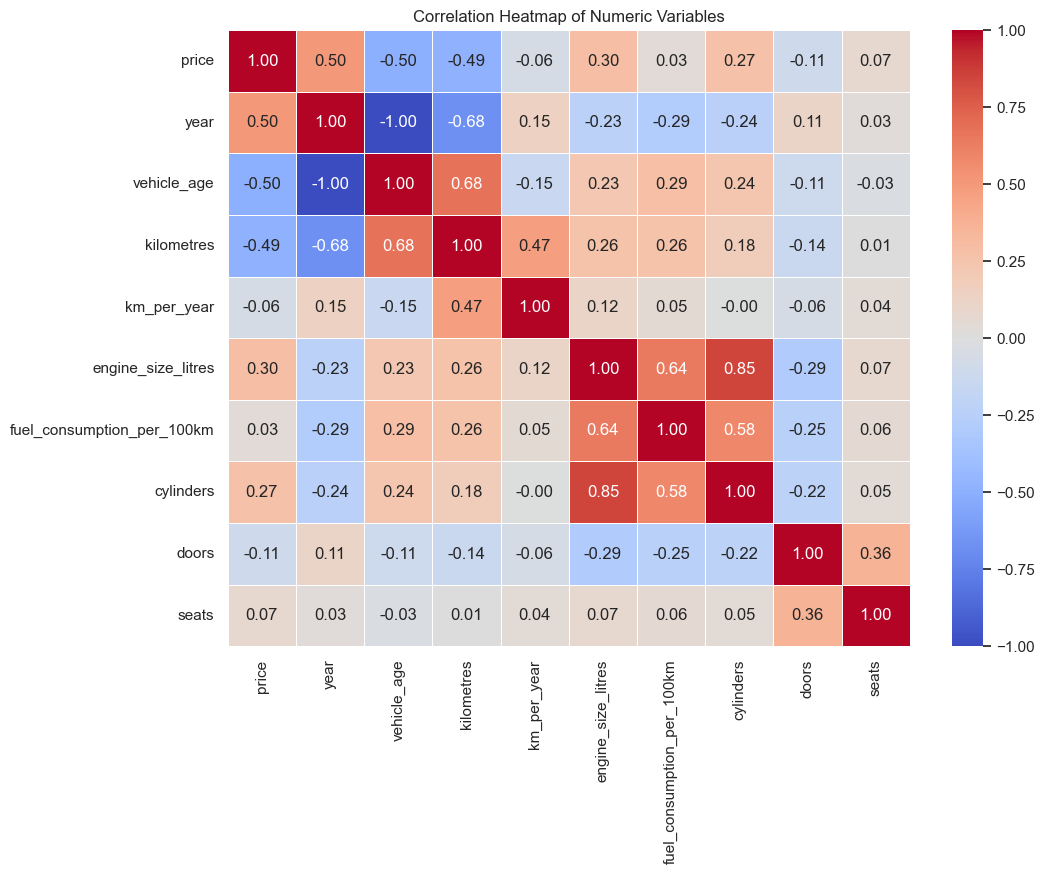

In [37]:
# Plot correlation heatmap for numeric predictors
correlation_cols = [
    "price",
    "year",
    "vehicle_age",
    "kilometres",
    "km_per_year",
    "engine_size_litres",
    "fuel_consumption_per_100km",
    "cylinders",
    "doors",
    "seats"
]

corr_matrix = df_eda_main_market[correlation_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


The heatmap reinforces several patterns observed in the scatterplots. `year` and `vehicle_age` are perfectly negatively correlated because `vehicle_age` was derived directly from `year`; both variables represent the same information, although `vehicle_age` provides a more intuitive view for EDA. The strongest numeric relationships with `price` are observed for `year`/`vehicle_age`, `kilometres`, `engine_size_litres`, and `cylinders`. As expected, older vehicles tend to have higher kilometres, producing a moderate positive correlation between `vehicle_age` and `kilometres`. There is also a clear cluster of related engine variables: `cylinders`, `engine_size_litres`, and `fuel_consumption_per_100km` are positively correlated, which is reasonable because larger engines and higher cylinder counts often use more fuel. In contrast, `fuel_consumption_per_100km`, `doors`, `seats`, and `km_per_year` show relatively weak direct correlations with `price`. The weak correlation for `km_per_year` supports the earlier observation that total kilometres and vehicle age appear to be more informative separately than the annualised usage rate alone.

### 4.3 Relationships Between Categorical Variables and Price

This section examines how used-car prices vary across categorical vehicle and listing characteristics. Variables with a relatively small number of categories can be compared using boxplots, which show differences in median price, spread, and potential outliers across groups.

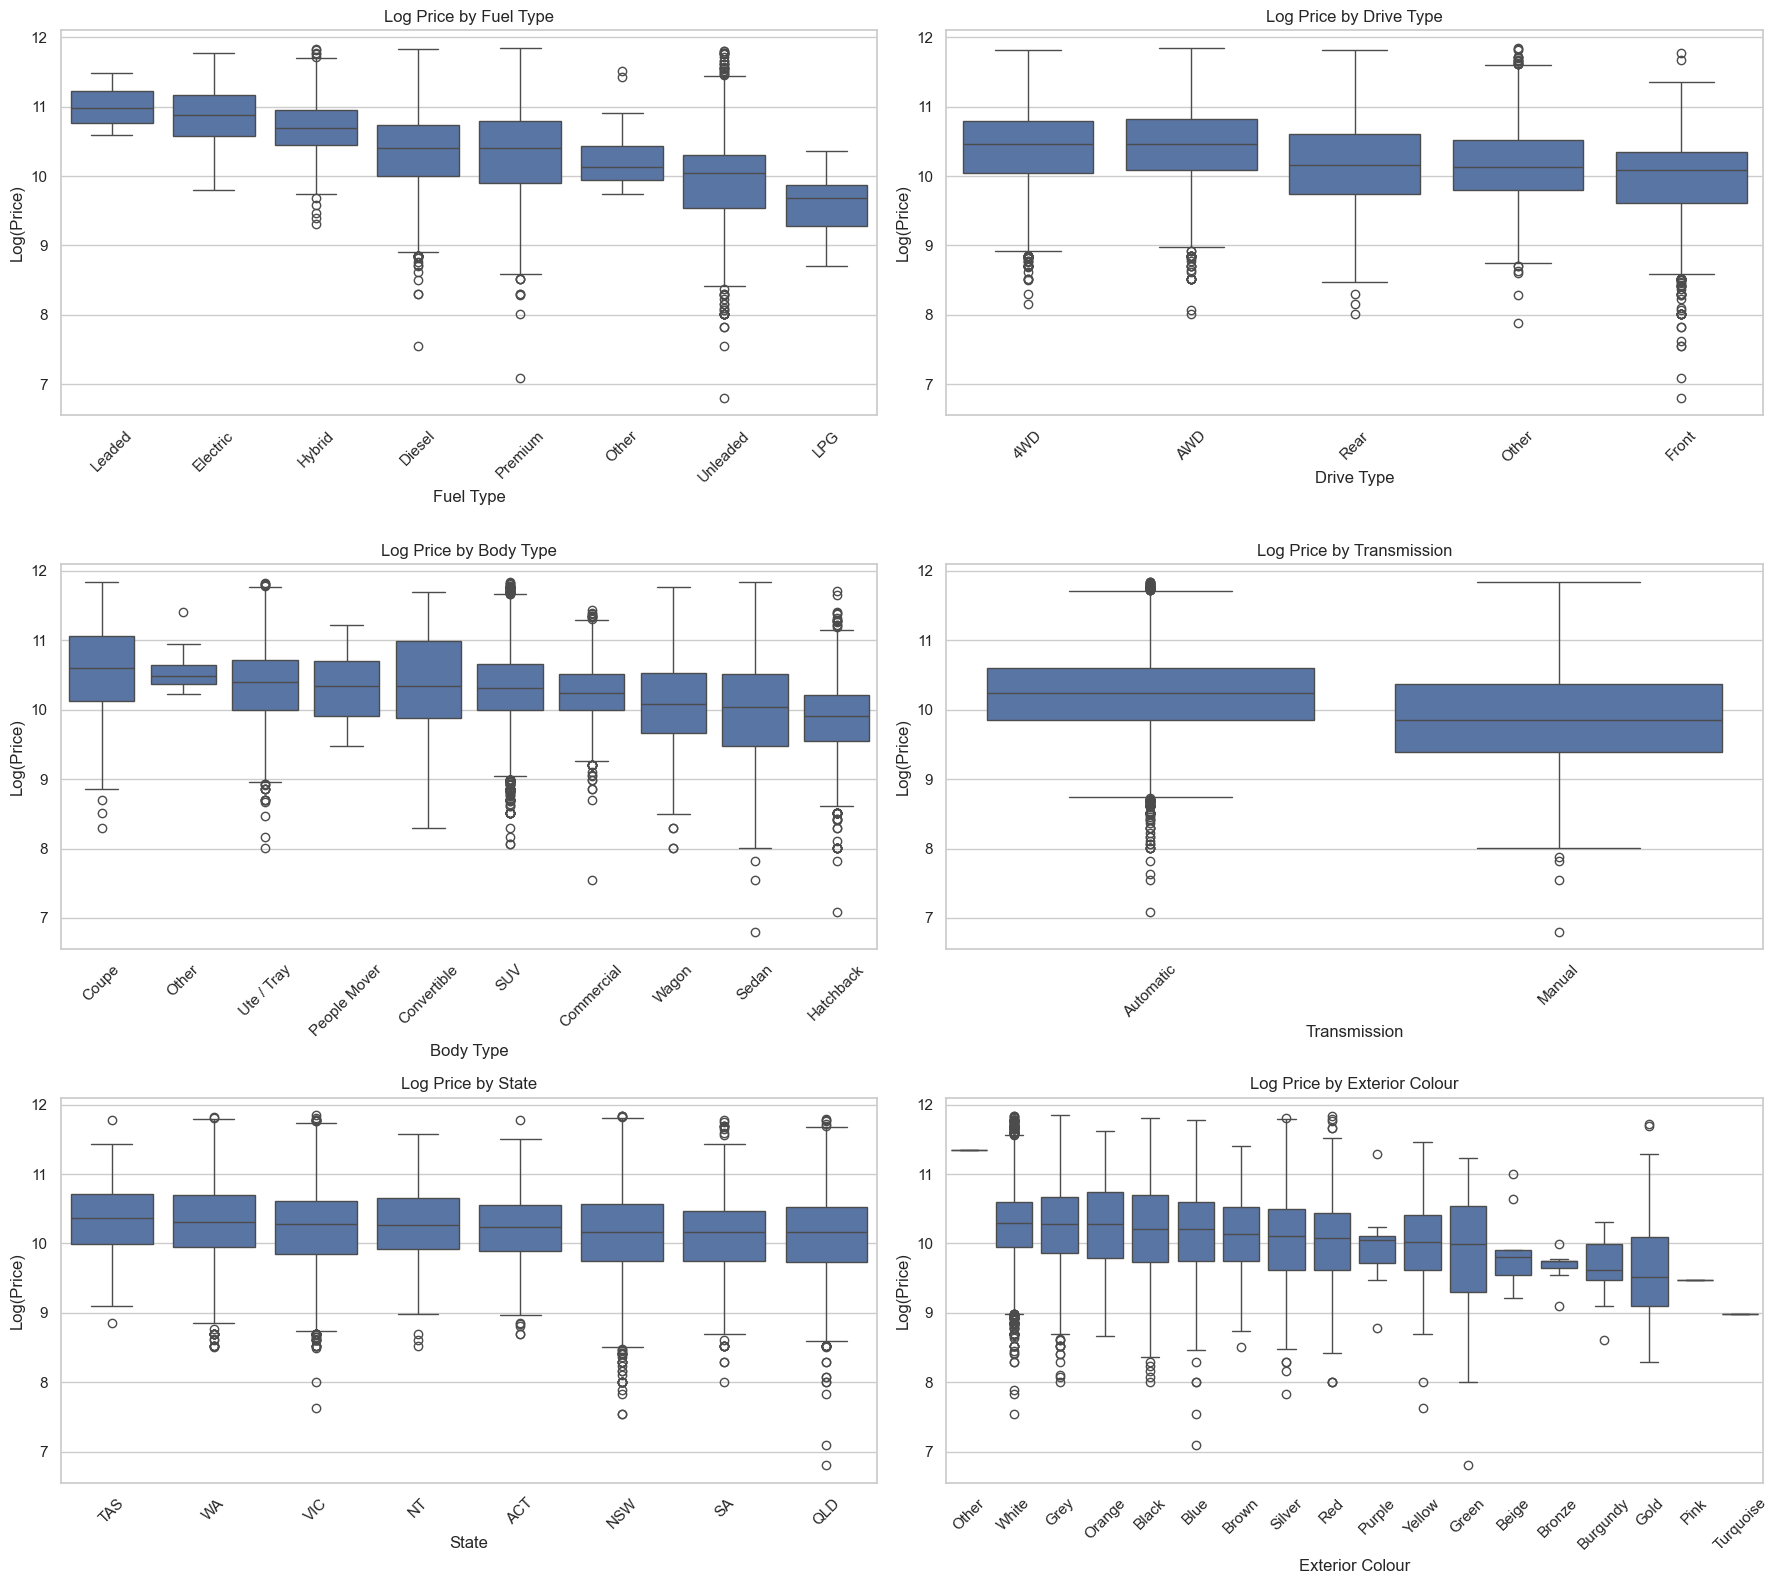

In [38]:
# Plot log-price distributions across lower-cardinality categorical variables
categorical_boxplot_cols = {
    "fuel_type": "Fuel Type",
    "drive_type": "Drive Type",
    "body_type": "Body Type",
    "transmission": "Transmission",
    "state": "State",
    "colour_ext": "Exterior Colour"
}

categorical_boxplot_data = df_eda_main_market.assign(log_price=np.log1p(df_eda_main_market["price"]))

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for ax, (col, label) in zip(axes, categorical_boxplot_cols.items()):
    order = categorical_boxplot_data.groupby(col, observed=True)["price"].median().sort_values(ascending=False).index
    sns.boxplot(
        data=categorical_boxplot_data,
        x=col,
        y="log_price",
        order=order,
        ax=ax
    )
    ax.set_title(f"Log Price by {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Log(Price)")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(categorical_boxplot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


The categorical boxplots show that some categorical predictors may help explain variation in used-car prices, although most relationships are not cleanly separated. `fuel_type` shows one of the clearer patterns, with leaded and electric vehicles generally appearing at higher price points than unleaded and LPG vehicles. However, the higher prices for leaded vehicles likely reflect that these listings are older classic or collector vehicles, rather than leaded fuel itself being a direct driver of price. `drive_type` also shows some separation, with AWD and 4WD vehicles having higher median prices and wider price ranges, likely reflecting differences in vehicle segment and capability. `body_type` and `transmission` also appear relevant, with coupes and convertibles showing wider price distributions and automatic vehicles generally selling for more than manual vehicles. In contrast, state-level differences are relatively small and heavily overlapping, suggesting that `state` may not be a strong standalone predictor. Exterior colour shows some variation between groups, but this relationship is noisy and may be affected by small category sizes rather than colour itself.

Higher-cardinality categorical variables require a more selective approach because plotting every category would be difficult to interpret. `brand`, `model`, and `colour_int` may still contain useful pricing information, so the analysis below focuses on the 15 most common values for each variable. In contrast, `title` is not examined directly because it is a high-cardinality advertisement text field that largely duplicates information already captured by `year`, `brand`, and `model`, while also containing inconsistent trim and listing-specific wording. `region` is also not examined in detail at this stage because the state-level price distributions were already highly overlapping, and suburb-level regions would introduce substantially more categories with smaller sample sizes.

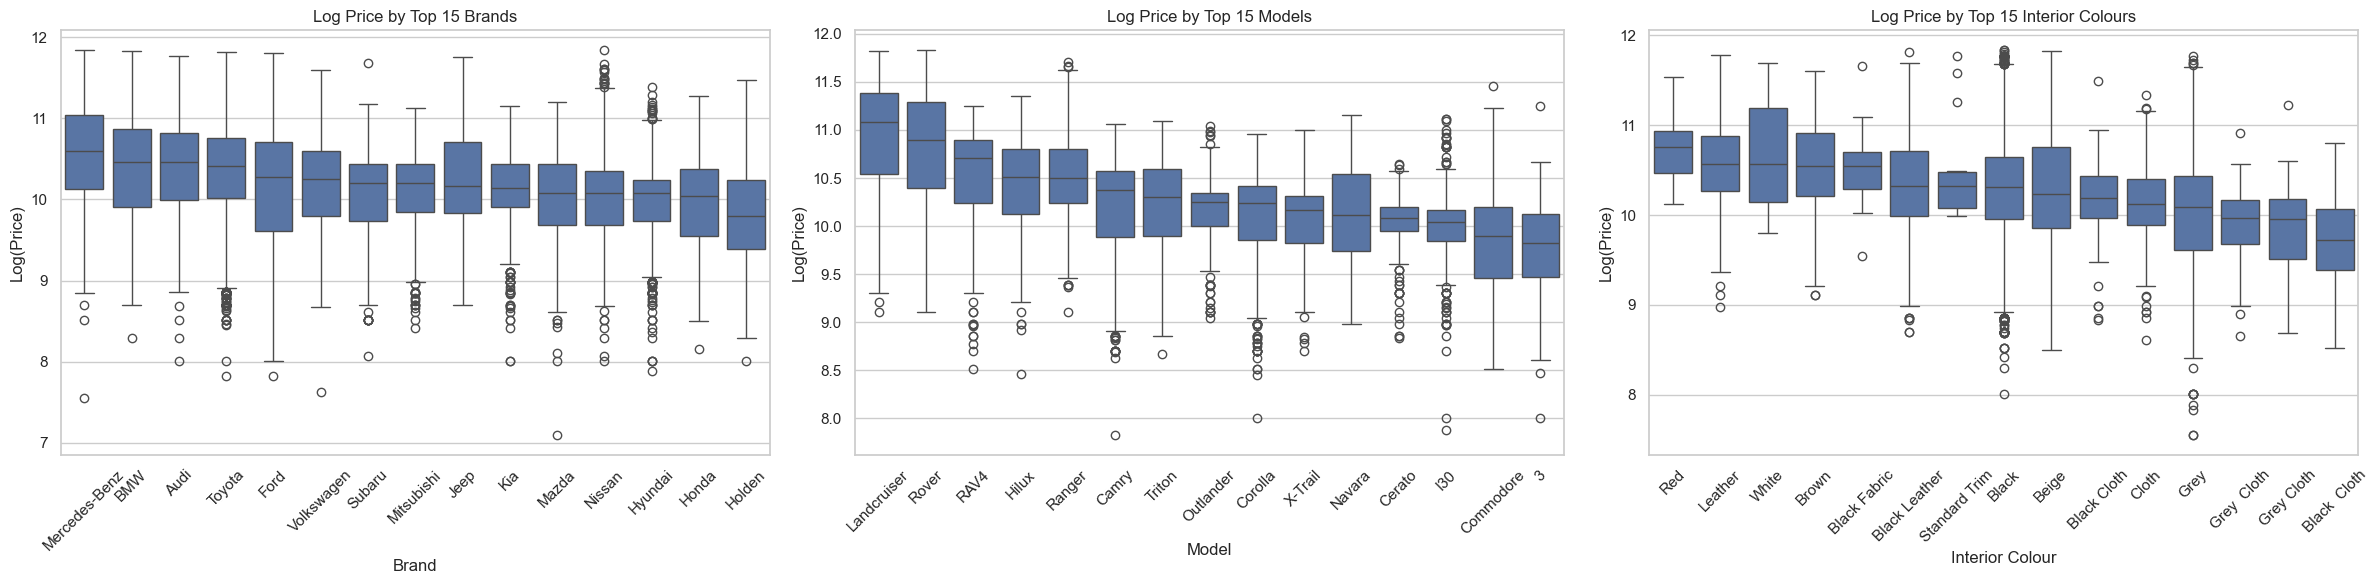

In [39]:
# Plot log-price distributions for selected high-cardinality categorical variables
high_cardinality_cols = {
    "brand": "Brand",
    "model": "Model",
    "colour_int": "Interior Colour"
}

high_cardinality_data = df_eda_main_market.assign(log_price=np.log1p(df_eda_main_market["price"]))

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, (col, label) in zip(axes, high_cardinality_cols.items()):
    top_categories = high_cardinality_data[col].value_counts().head(15).index
    plot_data = high_cardinality_data[high_cardinality_data[col].isin(top_categories)].copy()
    order = plot_data.groupby(col, observed=True)["price"].median().sort_values(ascending=False).index

    sns.boxplot(
        data=plot_data,
        x=col,
        y="log_price",
        order=order,
        ax=ax
    )
    ax.set_title(f"Log Price by Top 15 {label}s")
    ax.set_xlabel(label)
    ax.set_ylabel("Log(Price)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


The brand and model plots suggest that both variables contain useful pricing information, although their effects should be interpreted carefully. `brand` captures broad manufacturer-level differences, while `model` can provide more specific vehicle-level information. However, the model plot compares the most common models across the full dataset rather than comparing models within each brand, so the apparent differences between models may also reflect brand, body type, vehicle segment, and market-positioning effects. Interior colour also shows visible differences in price across common categories, with some colours and trim descriptions associated with higher median prices and wider price ranges. However, `colour_int` contains many missing values and inconsistent labels that mix colours, materials, and trim descriptions, so the raw field requires careful handling and is not treated as a modelling predictor in its current form.

### 4.4 EDA Summary

The exploratory analysis shows that used-car prices are strongly right-skewed, with most listings concentrated in the lower-to-middle price ranges and a small number of exotic, prestige, or collector vehicles extending the upper tail. These extreme listings are valid observations, but they are not representative of the intended prediction use case for typical used vehicles. Therefore, the modelling stage will focus on main-market used-car listings by retaining observations up to the 99th percentile of price, reducing the influence of rare high-price vehicles. The log-transformed price distribution was also more balanced than the raw price distribution, supporting the decision to train models on log-transformed price so that proportional errors are treated more consistently across vehicle price brackets.

Among the numeric predictors, `vehicle_age` and `kilometres` showed the clearest relationships with `price`, with newer vehicles and lower-kilometre vehicles generally listed at higher prices. `engine_size_litres` and `cylinders` also appeared relevant, while `km_per_year`, `doors`, `seats`, and `fuel_consumption_per_100km` showed weaker direct relationships with price. The correlation heatmap also highlighted expected relationships between predictors, including the perfect inverse relationship between `year` and `vehicle_age`, the positive relationship between `vehicle_age` and `kilometres`, and the cluster of related engine variables.

For categorical predictors, `fuel_type`, `drive_type`, `body_type`, `transmission`, `brand`, and `model` all showed some level of price separation. `model` appeared particularly informative because it captures more specific vehicle-level differences than brand alone, while `colour_int` also showed visible differences across common interior colour and trim categories. However, `colour_int` contains substantial missingness and inconsistent labels, so it is explored during EDA but excluded from the current modelling feature set. In contrast, `state` showed substantial overlap across price distributions, suggesting that it may not be a strong standalone predictor. Several data quality considerations were also identified, including zero values in engine-related variables and the need to handle high-cardinality fields such as `model` carefully during model preparation.

## 5. Predictive Modelling

The purpose of this section is to build and evaluate regression models that can predict used-car prices from the cleaned vehicle listing data. Based on the EDA findings, the modelling dataset will focus on main-market used-car listings by retaining observations up to the 99th percentile of price, as the project goal is to support predictions for typical used vehicles rather than rare exotic or collector listings. Because this predictive tool is built for average consumers, a 10% estimation error should be treated consistently across both lower- and higher-priced vehicles. Training a model on raw price can cause algorithms to favour minimising absolute dollar errors on expensive cars while producing less stable percentage errors on cheaper vehicles. Therefore, all models will be trained using the log-transformed price as the response variable to support more consistent percentage-error treatment across price brackets. A simpler baseline modelling approach will be trained first using standard preprocessing with numeric variables and lower-cardinality categorical predictors. This provides a reference point for model performance without immediately relying on the highest-cardinality feature, `model`. A CatBoost regressor will then be used as the primary modelling approach because it can handle categorical predictors directly, making it more suitable for important high-cardinality variables without expanding them into hundreds of one-hot encoded columns. Model performance will be compared using regression metrics such as MAE, MAPE, RMSE, and R-squared on the original dollar scale.

### 5.1 Feature and Target Definition

This subsection creates the modelling dataset, defines the target variable, and separates the predictors into two feature sets. To align the model with the intended use case of predicting typical used-car listings, `df_model` retains observations up to the 99th percentile of price. This removes rare high-price listings that are not representative of the average consumer prediction task. The target variable is stored on the original dollar scale, but the modelling pipelines will apply the log transformation internally during training and then convert predictions back to dollars for evaluation. The baseline feature set uses numeric variables and lower-cardinality categorical variables that can be handled with standard preprocessing, while the CatBoost feature set also includes `model` because CatBoost can work with higher-cardinality categorical predictors directly.

In [40]:
# Create modelling dataset for main-market used-car listings
model_price_upper = df_clean["price"].quantile(0.99)
df_model = df_clean[df_clean["price"] <= model_price_upper].copy()

# Define target variable
target_col = "price"
y = df_model[target_col].astype("float64").copy()

# Baseline models use numeric predictors and lower-cardinality categorical variables
baseline_numeric_features = [
    "year",
    "kilometres",
    "engine_size_litres",
    "fuel_consumption_per_100km",
    "cylinders",
    "doors",
    "seats"
]

baseline_categorical_features = [
    "brand",
    "transmission",
    "body_type",
    "fuel_type",
    "drive_type",
    "state",
    "colour_ext"
]

baseline_features = baseline_numeric_features + baseline_categorical_features
X_baseline = df_model[baseline_features].copy()
X_baseline = X_baseline.astype("object").where(pd.notna(X_baseline), np.nan)
X_baseline[baseline_numeric_features] = X_baseline[baseline_numeric_features].astype("float64")

# CatBoost can use high-cardinality categorical predictors directly
catboost_numeric_features = baseline_numeric_features.copy()
catboost_categorical_features = baseline_categorical_features + ["model"]
catboost_features = catboost_numeric_features + catboost_categorical_features
X_catboost = df_model[catboost_features].copy()
X_catboost = X_catboost.astype("object").where(pd.notna(X_catboost), np.nan)
X_catboost[catboost_numeric_features] = X_catboost[catboost_numeric_features].astype("float64")

# Inspect categorical cardinality
display(Markdown("### Categorical feature cardinality"))
categorical_cardinality = pd.DataFrame({
    "feature": catboost_categorical_features,
    "unique_values": [X_catboost[col].nunique(dropna=False) for col in catboost_categorical_features]
}).sort_values("unique_values", ascending=False)
display(categorical_cardinality)

# Check missing values across the modelling predictors
display(Markdown("### Missing values in modelling predictors"))
modelling_missing = df_model[catboost_features].isna().sum().sort_values(ascending=False)
display(modelling_missing[modelling_missing > 0].to_frame("Missing values"))


### Categorical feature cardinality

,feature,unique_values
7,model,686
0,brand,66
6,colour_ext,19
2,body_type,11
3,fuel_type,9
5,state,8
4,drive_type,5
1,transmission,3


### Missing values in modelling predictors

,Missing values
fuel_consumption_per_100km,1444
seats,1444
engine_size_litres,1421
cylinders,1421
doors,1421
fuel_type,407
colour_ext,358
body_type,258
transmission,164
kilometres,9


The remaining missing values occur only in predictor variables, so these rows will be retained rather than removed. Numeric missing values will be imputed using the median from the training data, as this provides a robust central value that is less affected by outliers than the mean. Categorical missing values will be treated as a separate `Missing` category rather than being replaced with the most common category, as mode imputation could assign vehicle characteristics that were not recorded. For the Ridge regression baseline, numeric variables will also be scaled after imputation because the predictors are measured on very different scales, such as kilometres compared with doors or seats. These preprocessing steps will be applied within the modelling pipelines after the train/test split to avoid data leakage.

### 5.2 Train and Test Split

The cleaned dataset is split into training and testing sets using an 80/20 split. The same row indices are used for both the baseline and CatBoost feature sets so that all models are trained and evaluated on directly comparable observations.

In [41]:
# Create a shared train/test split for all modelling approaches
train_index, test_index = train_test_split(
    df_model.index,
    test_size=0.20,
    random_state=42
)

# Baseline feature split
X_baseline_train = X_baseline.loc[train_index].copy()
X_baseline_test = X_baseline.loc[test_index].copy()

# CatBoost feature split
X_catboost_train = X_catboost.loc[train_index].copy()
X_catboost_test = X_catboost.loc[test_index].copy()

# Target split
y_train = y.loc[train_index].copy()
y_test = y.loc[test_index].copy()


The final modelling dataframe, train/test split indices, and feature metadata are exported so the dashboard interval model can be trained from the exact same cleaned data and predictor set.


In [42]:
model_input_dir = MODEL_INPUT_DIR
model_input_dir.mkdir(parents=True, exist_ok=True)


def write_text_if_changed(path, text):
    """Write an export file only when its contents have changed."""
    if path.exists() and path.read_text(encoding="utf-8") == text:
        print(f"Skipped unchanged export: {path}")
        return

    try:
        path.write_text(text, encoding="utf-8")
        print(f"Exported: {path}")
    except PermissionError as exc:
        raise PermissionError(
            f"Could not write {path}. Close any program using this file "
            "such as Excel, a file preview, the dashboard app, or OneDrive sync, "
            "then rerun this cell."
        ) from exc


# Export the exact modelling dataframe used by the final point-estimate model
write_text_if_changed(
    model_input_dir / "used_car_modelling_dataset.csv",
    df_model.to_csv(index=True, index_label="modelling_index"),
)

# Export the exact train/test split indices
write_text_if_changed(
    model_input_dir / "used_car_train_index.csv",
    pd.Series(train_index, name="modelling_index").to_csv(index=False),
)

write_text_if_changed(
    model_input_dir / "used_car_test_index.csv",
    pd.Series(test_index, name="modelling_index").to_csv(index=False),
)

# Export feature metadata so the interval notebook uses the same predictors
model_metadata = {
    "target_col": target_col,
    "model_price_upper": float(model_price_upper),
    "catboost_numeric_features": catboost_numeric_features,
    "catboost_categorical_features": catboost_categorical_features,
    "catboost_features": catboost_features,
    "test_size": 0.20,
    "random_state": 42,
    "cv_folds": 5,
    "target_transform": "log1p",
    "inverse_target_transform": "expm1",
}

write_text_if_changed(
    model_input_dir / "used_car_modelling_metadata.json",
    json.dumps(model_metadata, indent=4),
)

Exported: c:\Users\User\OneDrive\Desktop\Coding\Python\data_science_projects\used-car-price-prediction\data\model_inputs\used_car_modelling_dataset.csv
Exported: c:\Users\User\OneDrive\Desktop\Coding\Python\data_science_projects\used-car-price-prediction\data\model_inputs\used_car_train_index.csv
Exported: c:\Users\User\OneDrive\Desktop\Coding\Python\data_science_projects\used-car-price-prediction\data\model_inputs\used_car_test_index.csv
Skipped unchanged export: c:\Users\User\OneDrive\Desktop\Coding\Python\data_science_projects\used-car-price-prediction\data\model_inputs\used_car_modelling_metadata.json


### 5.3 Model Pipelines

This subsection defines the preprocessing and modelling pipelines used for comparison. Ridge regression is included as a simple linear baseline and requires numeric scaling after imputation. Ridge is used instead of Lasso because the aim of this baseline is stable regularised prediction rather than feature selection; Ridge shrinks coefficients while retaining all predictors, which is useful when the feature set includes correlated numeric variables and one-hot encoded categorical levels. Random Forest is used as a stronger non-linear baseline that can capture more complex relationships without scaling. CatBoost is then prepared as the primary model because it can use categorical predictors directly, including the high-cardinality `model` variable, without one-hot encoding it into hundreds of separate columns. All three models are wrapped in `TransformedTargetRegressor`, which applies `np.log1p` to `price` during training and converts predictions back to dollars using `np.expm1`. This keeps evaluation interpretable on the original dollar scale while training the models to focus more evenly on percentage errors across lower- and higher-priced vehicles. CatBoost still uses `loss_function="RMSE"` inside the wrapped model because RMSE provides stable optimisation on the transformed log-price scale.

In [43]:
# Preprocessing for Ridge regression
ridge_numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

baseline_categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ridge_preprocessor = ColumnTransformer(transformers=[
    ("numeric", ridge_numeric_preprocessor, baseline_numeric_features),
    ("categorical", baseline_categorical_preprocessor, baseline_categorical_features)
])

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", ridge_preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=Ridge(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

# Preprocessing for Random Forest
random_forest_numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

random_forest_preprocessor = ColumnTransformer(transformers=[
    ("numeric", random_forest_numeric_preprocessor, baseline_numeric_features),
    ("categorical", baseline_categorical_preprocessor, baseline_categorical_features)
])

random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", random_forest_preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

# Preprocessing for CatBoost
catboost_numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

catboost_categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing"))
])

catboost_preprocessor = ColumnTransformer(transformers=[
    ("numeric", catboost_numeric_preprocessor, catboost_numeric_features),
    ("categorical", catboost_categorical_preprocessor, catboost_categorical_features)
])

catboost_categorical_indices = list(
    range(len(catboost_numeric_features), len(catboost_features))
)

class CatBoostWithCategoricalFeatures(RegressorMixin, BaseEstimator):
    def __init__(self, cat_features=None, loss_function="RMSE", random_state=42, verbose=False):
        self.cat_features = cat_features
        self.loss_function = loss_function
        self.random_state = random_state
        self.verbose = verbose

    def fit(self, X, y, **fit_params):
        self.model_ = CatBoostRegressor(
            loss_function=self.loss_function,
            random_state=self.random_state,
            verbose=self.verbose
        )
        self.model_.fit(
            X,
            y,
            cat_features=list(self.cat_features) if self.cat_features is not None else None
        )
        return self

    def predict(self, X):
        return self.model_.predict(X)


catboost_pipeline = Pipeline(steps=[
    ("preprocessor", catboost_preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=CatBoostWithCategoricalFeatures(
            cat_features=tuple(catboost_categorical_indices),
            loss_function="RMSE",
            random_state=42,
            verbose=False
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

model_pipelines = {
    "Ridge Regression": ridge_pipeline,
    "Random Forest": random_forest_pipeline,
    "CatBoost": catboost_pipeline
}

# Summarise modelling approaches
model_pipeline_summary = pd.DataFrame({
    "model": [
        "Ridge Regression",
        "Random Forest",
        "CatBoost"
    ],
    "feature_set": [
        "Baseline predictors",
        "Baseline predictors",
        "CatBoost predictors"
    ],
    "numeric_preprocessing": [
        "Median imputation and scaling",
        "Median imputation",
        "Median imputation"
    ],
    "categorical_preprocessing": [
        "Missing category and one-hot encoding",
        "Missing category and one-hot encoding",
        "Missing category with native categorical handling"
    ],
    "target": [
        "Log-transformed price",
        "Log-transformed price",
        "Log-transformed price"
    ]
})

display(model_pipeline_summary)


,model,feature_set,numeric_preprocessing,categorical_preprocessing,target
0,Ridge Regression,Baseline predictors,Median imputation and scaling,Missing category and one-hot encoding,Log-transformed price
1,Random Forest,Baseline predictors,Median imputation,Missing category and one-hot encoding,Log-transformed price
2,CatBoost,CatBoost predictors,Median imputation,Missing category with native categorical handling,Log-transformed price


### 5.4 Evaluation Functions

The following functions are defined to evaluate model performance consistently. Cross-validation will be used first on the training data to compare model performance and stability across folds, while final test-set evaluation will be reserved for later after the modelling approach has been selected.

In [44]:
# Reusable cross-validation function for regression models
def evaluate_cross_validation(model, X, y, model_name, cv, n_jobs=None):
    scoring = {
        "MAE": "neg_mean_absolute_error",
        "MAPE": "neg_mean_absolute_percentage_error",
        "RMSE": "neg_root_mean_squared_error",
        "R-squared": "r2"
    }

    cv_scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
    )

    fold_results = pd.DataFrame({
        "MAE": -cv_scores["test_MAE"],
        "MAPE": -cv_scores["test_MAPE"] * 100,
        "RMSE": -cv_scores["test_RMSE"],
        "R-squared": cv_scores["test_R-squared"],
    })

    fold_results.index = range(1, len(fold_results) + 1)
    fold_results.index.name = "Fold"

    summary = pd.DataFrame({
        "Mean": fold_results.mean(),
        "Standard Deviation": fold_results.std(),
    })

    display(Markdown(f"### {model_name} Cross-Validation Results"))
    display(fold_results)

    display(Markdown("### Cross-Validation Summary"))
    display(summary)

    return summary


# Reusable function for comparing cross-validation summaries
def compare_cross_validation_summaries(cv_summaries):
    comparison = pd.DataFrame({
        model_name: {
            **results["Mean"].to_dict(),
            "MAE Standard Deviation": results.loc[
                "MAE",
                "Standard Deviation",
            ],
            "MAPE Standard Deviation": results.loc[
                "MAPE",
                "Standard Deviation",
            ],
            "RMSE Standard Deviation": results.loc[
                "RMSE",
                "Standard Deviation",
            ],
            "R-squared Standard Deviation": results.loc[
                "R-squared",
                "Standard Deviation",
            ],
        }
        for model_name, results in cv_summaries.items()
    }).T.sort_values("RMSE")

    return comparison[
        [
            "MAE",
            "MAPE",
            "RMSE",
            "R-squared",
            "MAE Standard Deviation",
            "MAPE Standard Deviation",
            "RMSE Standard Deviation",
            "R-squared Standard Deviation",
        ]
    ]


def evaluate_test_performance(model_name, pipeline, X_train, X_test, y_train, y_test):
    """Fit a model on the full training set and evaluate it on the test set."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    test_results = pd.DataFrame({
        "MAE": [mean_absolute_error(y_test, y_pred)],
        "MAPE": [mean_absolute_percentage_error(y_test, y_pred) * 100],
        "RMSE": [root_mean_squared_error(y_test, y_pred)],
        "R-squared": [r2_score(y_test, y_pred)]
    }, index=[model_name])

    display(Markdown(f"### {model_name} Test Set Performance"))
    display(test_results)

    return pipeline, test_results, y_pred


### 5.5 Model Training and Evaluation

The models are first evaluated using cross-validation on the training data. This allows each model to be assessed across multiple folds before the held-out test set is used for final evaluation. Since all models are trained on the log-transformed target, the comparison focuses on whether the model structure and feature set improve prediction accuracy after applying the same response transformation strategy.

#### 5.5.1 Ridge Regression Baseline

Ridge regression is used as the first baseline model. This provides a simple regularised linear model for comparison, using the baseline predictor set with median imputation, numeric scaling, and one-hot encoding for categorical variables. The response variable is log-transformed inside the pipeline so that the baseline model is trained using the same target strategy as the later models.

In [45]:
# Evaluate Ridge regression using cross-validation on the training data
ridge_cv_summary = evaluate_cross_validation(
    model=ridge_pipeline,
    X=X_baseline_train,
    y=y_train,
    model_name="Ridge Regression",
    cv=5,
    n_jobs=-1,
)


### Ridge Regression Cross-Validation Results

,MAE,MAPE,RMSE,R-squared
Fold,,,,
1,5732.232,18.690,9970.810,0.756
2,5860.714,19.295,9904.070,0.756
3,5612.456,18.469,9032.642,0.788
4,5745.054,18.830,10304.915,0.740
5,5873.178,18.958,10525.077,0.743


### Cross-Validation Summary

,Mean,Standard Deviation
MAE,5764.727,106.776
MAPE,18.848,0.308
RMSE,9947.503,570.249
R-squared,0.757,0.019


The Ridge regression model provides a useful first benchmark for the modelling stage. Because it is trained on the log-transformed target, its predictions are encouraged to reflect proportional price differences rather than only absolute dollar differences. However, Ridge is still a linear model, so any remaining error may reflect non-linear relationships and interactions that cannot be fully captured by this baseline structure.

#### 5.5.2 Random Forest Regression Baseline

Random Forest regression is evaluated as a non-linear baseline model. Unlike Ridge regression, Random Forest can capture more complex relationships and interactions between predictors without requiring numeric scaling. It still uses the baseline predictor set, meaning that the high-cardinality `model` variable is not included at this stage. The model is also trained on the log-transformed target so that its results are directly comparable with the other models.

In [46]:
# Evaluate Random Forest regression using cross-validation on the training data
random_forest_cv_summary = evaluate_cross_validation(
    model=random_forest_pipeline,
    X=X_baseline_train,
    y=y_train,
    model_name="Random Forest",
    cv=5,
)


### Random Forest Cross-Validation Results

,MAE,MAPE,RMSE,R-squared
Fold,,,,
1,4597.701,15.337,8588.537,0.819
2,4485.683,15.204,8141.179,0.835
3,4426.196,14.907,7400.398,0.858
4,4541.540,15.445,8087.353,0.840
5,4721.932,15.508,8792.071,0.821


### Cross-Validation Summary

,Mean,Standard Deviation
MAE,4554.610,113.209
MAPE,15.280,0.238
RMSE,8201.908,537.821
R-squared,0.835,0.016


The Random Forest model provides a stronger non-linear baseline than Ridge regression. Any improvement over Ridge would suggest that allowing for non-linear relationships and interactions between predictors improves used-car price prediction, even before introducing the high-cardinality `model` variable used by CatBoost.

#### 5.5.3 CatBoost Regression

CatBoost is evaluated as the primary modelling approach because it can handle categorical predictors directly, including the high-cardinality `model` variable. This allows the model to use more specific vehicle information without expanding `model` into hundreds of one-hot encoded columns. CatBoost is still trained with a stable RMSE objective, but because it is wrapped inside `TransformedTargetRegressor`, that objective is applied to the log-transformed price response.

In [47]:
# Evaluate CatBoost regression using cross-validation on the training data
catboost_cv_summary = evaluate_cross_validation(
    model=catboost_pipeline,
    X=X_catboost_train,
    y=y_train,
    model_name="CatBoost",
    cv=5,
)


### CatBoost Cross-Validation Results

,MAE,MAPE,RMSE,R-squared
Fold,,,,
1,3967.163,12.968,7345.500,0.868
2,3932.264,13.045,7071.602,0.876
3,3861.793,12.862,6412.903,0.893
4,3853.946,12.900,6712.856,0.890
5,4096.281,13.256,7478.050,0.870


### Cross-Validation Summary

,Mean,Standard Deviation
MAE,3942.289,98.383
MAPE,13.006,0.156
RMSE,7004.182,441.609
R-squared,0.879,0.012


The CatBoost cross-validation results complete the initial model training stage by evaluating the model that can directly use the high-cardinality `model` predictor. This provides the key comparison against the Ridge and Random Forest baselines before selecting a final model for held-out test-set evaluation.

#### 5.5.4 Initial Model Comparison

In [48]:
# Combine cross-validation summaries for initial model comparison
model_cv_summaries = {
    "Ridge Regression": ridge_cv_summary,
    "Random Forest": random_forest_cv_summary,
    "CatBoost": catboost_cv_summary,
}

model_comparison = compare_cross_validation_summaries(model_cv_summaries)

display(Markdown("### Models Cross-Validation Performance"))
display(model_comparison)


### Models Cross-Validation Performance

,MAE,MAPE,RMSE,R-squared,MAE Standard Deviation,MAPE Standard Deviation,RMSE Standard Deviation,R-squared Standard Deviation
CatBoost,3942.289,13.006,7004.182,0.879,98.383,0.156,441.609,0.012
Random Forest,4554.610,15.280,8201.908,0.835,113.209,0.238,537.821,0.016
Ridge Regression,5764.727,18.848,9947.503,0.757,106.776,0.308,570.249,0.019


Based on the initial cross-validation comparison, CatBoost is selected as the preferred model for final evaluation. It achieved the strongest overall performance across the tested models, with lower prediction errors and stronger explanatory performance than the Ridge and Random Forest baselines. The final step is to fit CatBoost on the full training data and evaluate it on the held-out test set.

### 5.6 Final Model Evaluation and Interpretation

The selected CatBoost model is fitted on the full training dataset and evaluated on the held-out test dataset. Because this test set was not used during model training or cross-validation, it provides an unbiased estimate of the model's performance on unseen used-car listings.

In [49]:
# Fit the selected CatBoost model on the full training data and evaluate on the test data
final_catboost_model, catboost_test_results, catboost_test_predictions = evaluate_test_performance(
    model_name="CatBoost",
    pipeline=catboost_pipeline,
    X_train=X_catboost_train,
    X_test=X_catboost_test,
    y_train=y_train,
    y_test=y_test
)


### CatBoost Test Set Performance

,MAE,MAPE,RMSE,R-squared
CatBoost,3840.927,12.976,6320.822,0.897


In [50]:
# Inspect a sample of actual and predicted test-set prices
catboost_test_predictions_df = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": catboost_test_predictions
})

catboost_test_predictions_df["residual"] = (
    catboost_test_predictions_df["actual_price"] -
    catboost_test_predictions_df["predicted_price"]
)

catboost_test_predictions_df["absolute_percentage_error"] = (
    catboost_test_predictions_df["residual"].abs() /
    catboost_test_predictions_df["actual_price"]
) * 100

display(Markdown("### Sample of CatBoost test-set predictions"))
display(catboost_test_predictions_df.head(10))


### Sample of CatBoost test-set predictions

,actual_price,predicted_price,residual,absolute_percentage_error
2629,8499.000,10461.884,-1962.884,23.095
4103,22890.000,20488.462,2401.538,10.492
9605,12499.000,14727.710,-2228.710,17.831
7163,37990.000,37897.006,92.994,0.245
14945,19988.000,25969.670,-5981.670,29.926
381,26888.000,22544.457,4343.543,16.154
4530,19990.000,24898.684,-4908.684,24.556
11511,54990.000,55213.652,-223.652,0.407
305,32980.000,31284.762,1695.238,5.140
4986,17750.000,22285.807,-4535.807,25.554


The selected CatBoost model demonstrated strong predictive performance on the unseen test set, achieving an R-squared value of 0.897 and a MAPE of 12.98%. These results indicate that the model is capable of producing reasonably accurate price estimates across a broad range of used vehicles, with predictions typically differing from the actual vehicle price by approximately 13%. Inspection of the sample predictions shows that the model generally produces realistic price estimates, although some vehicles exhibit larger prediction errors. These larger errors are expected given the complexity of the used-car market and the influence of factors that are not fully represented within the available dataset. Although the evaluation metrics indicate that the model performs well overall, further insight can be gained by examining the residuals. Residual analysis helps assess whether prediction errors are randomly distributed and highlights any systematic patterns that may not be evident from the summary metrics alone.

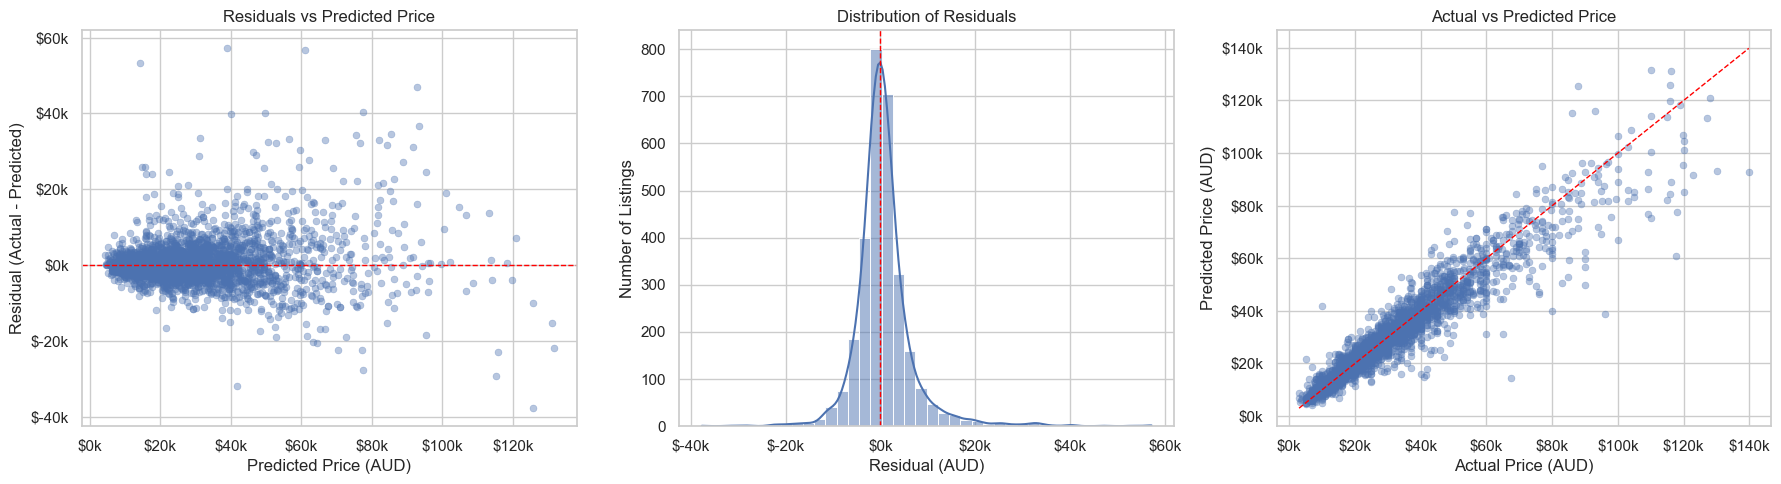

In [51]:
# Residual analysis for final CatBoost model
residuals = catboost_test_predictions_df["residual"]
predicted_prices = catboost_test_predictions_df["predicted_price"]
actual_prices = catboost_test_predictions_df["actual_price"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs predicted prices
sns.scatterplot(
    x=predicted_prices,
    y=residuals,
    alpha=0.4,
    s=25,
    edgecolor=None,
    ax=axes[0]
)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs Predicted Price")
axes[0].set_xlabel("Predicted Price (AUD)")
axes[0].set_ylabel("Residual (Actual - Predicted)")

# Residual distribution
sns.histplot(
    residuals,
    bins=40,
    kde=True,
    ax=axes[1]
)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual (AUD)")
axes[1].set_ylabel("Number of Listings")

# Actual vs predicted prices
sns.scatterplot(
    x=actual_prices,
    y=predicted_prices,
    alpha=0.4,
    s=25,
    edgecolor=None,
    ax=axes[2]
)

price_min = min(actual_prices.min(), predicted_prices.min())
price_max = max(actual_prices.max(), predicted_prices.max())

axes[2].plot(
    [price_min, price_max],
    [price_min, price_max],
    color="red",
    linestyle="--",
    linewidth=1
)
axes[2].set_title("Actual vs Predicted Price")
axes[2].set_xlabel("Actual Price (AUD)")
axes[2].set_ylabel("Predicted Price (AUD)")

for ax in axes:
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x / 1000:.0f}k"))
    if ax != axes[1]:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y / 1000:.0f}k"))

plt.tight_layout()
plt.show()

The residual analysis provides additional evidence that the CatBoost model generalises well to unseen data. Residuals are centred close to zero and the error distribution is approximately symmetric, indicating that the model does not exhibit a strong overall prediction bias across the test set. However, the diagnostic plots also show that prediction uncertainty increases as vehicle price increases, with higher-priced vehicles displaying greater dispersion around the predicted values than lower- and mid-priced vehicles. This suggests that, although the model captures the overall relationship between the predictor variables and vehicle price, predictions become less precise for more expensive vehicles where pricing is potentially more variable and more difficult to model accurately. Overall, the residual analysis supports the conclusion that the model provides useful predictions across the majority of the dataset while highlighting the greater uncertainty associated with higher-value vehicles.

Having established that the model generalises well to unseen data, the feature importance scores are now examined to identify the predictor variables that contribute most strongly to the CatBoost model's predictions.

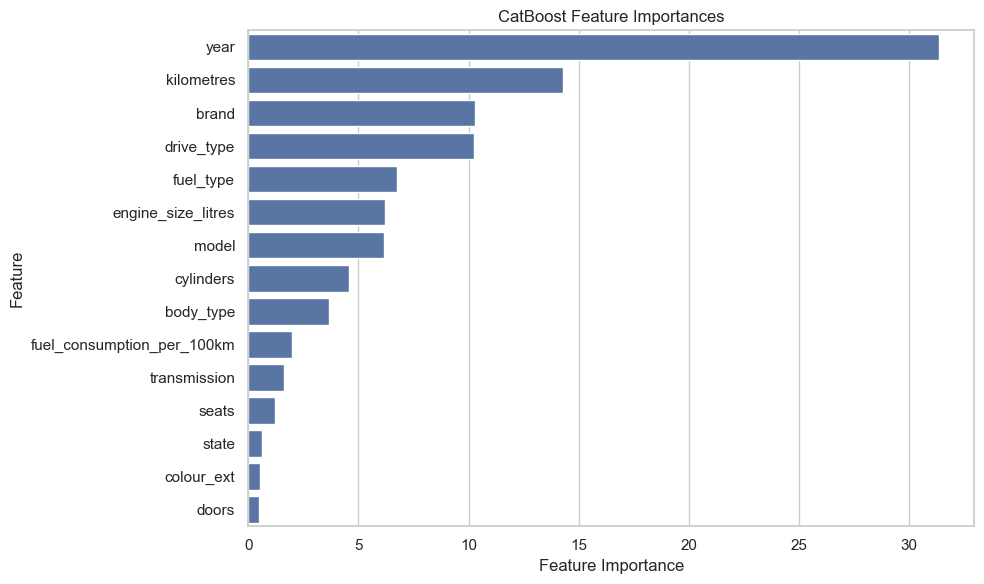

In [52]:
# Plot CatBoost feature importance
catboost_regressor = (
    final_catboost_model
    .named_steps["model"]
    .regressor_
    .model_
)

catboost_feature_names = catboost_numeric_features + catboost_categorical_features

feature_importance = pd.DataFrame({
    "feature": catboost_feature_names,
    "importance": catboost_regressor.get_feature_importance()
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)
plt.title("CatBoost Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The feature importance plot shows that `year` and `kilometres` are the most influential predictors in the final CatBoost model, which aligns with the EDA results where newer vehicles and lower-kilometre vehicles were generally associated with higher prices. `brand` is also highly important, suggesting that broad manufacturer-level market positioning provides useful information for price prediction. Although `model` is still important, its lower importance relative to `brand` should be interpreted carefully. The EDA comparison of top models was based on the most common models across the full dataset, rather than comparing models within each brand. Therefore, the apparent differences between models may partly reflect brand, body type, and vehicle segment differences rather than the independent effect of model alone.

In the CatBoost model, `brand` may provide a strong early split because it captures broad pricing differences across manufacturers, while `model` provides more specific information within those broader groups. However, because `model` has much higher cardinality, with many individual model categories having fewer observations, its importance may be spread across many smaller category-level effects. This means `brand` can appear more important overall even though `model` remains a useful predictor for refining predictions.

`drive_type` and `fuel_type` also appear important, indicating that drivetrain and fuel configuration contribute meaningful pricing information beyond age, kilometres, and brand. This may reflect differences in vehicle segment, buyer preferences, and the market value of categories such as 4WD, AWD, hybrid, diesel, or electric vehicles. In contrast, variables such as `doors`, `seats`, `colour_ext`, `state`, `transmission`, `fuel_consumption_per_100km`, and `body_type` show lower importance. This does not necessarily mean that these features are irrelevant, but their information may already be partially captured by stronger predictors such as `brand`, `model`, `year`, and `kilometres`. For example, many vehicle models are closely associated with particular body types, cylinder counts, fuel consumption ranges, and seating configurations, meaning these variables may add less additional splitting value once the model already knows the brand and model.

### 5.7 Sample Predictions

To demonstrate how the final CatBoost model can be used in practice, a small set of example vehicle listings is created and passed through the trained model. These examples are not used to evaluate model performance, as the formal evaluation has already been completed using the held-out test set. Instead, they provide an illustrative view of how the model generates price estimates for dashboard-style user inputs.


In [53]:
# Create example vehicle listings for sample predictions
sample_vehicles = pd.DataFrame([
    {
        "year": 2013,
        "kilometres": 145000,
        "engine_size_litres": 4.0,
        "fuel_consumption_per_100km": 9.9,
        "cylinders": 6,
        "doors": 4,
        "seats": 5,
        "brand": "Ford",
        "transmission": "Automatic",
        "body_type": "Sedan",
        "fuel_type": "Unleaded",
        "drive_type": "Rear",
        "state": "SA",
        "colour_ext": "Grey",
        "model": "Falcon"
    },
    {
        "year": 2018,
        "kilometres": 85000,
        "engine_size_litres": 2.0,
        "fuel_consumption_per_100km": 7.4,
        "cylinders": 4,
        "doors": 5,
        "seats": 5,
        "brand": "Mazda",
        "transmission": "Automatic",
        "body_type": "SUV",
        "fuel_type": "Unleaded",
        "drive_type": "Front",
        "state": "NSW",
        "colour_ext": "Grey",
        "model": "CX-5"
    },
    {
        "year": 2020,
        "kilometres": 65000,
        "engine_size_litres": 2.8,
        "fuel_consumption_per_100km": 8.4,
        "cylinders": 4,
        "doors": 4,
        "seats": 5,
        "brand": "Toyota",
        "transmission": "Automatic",
        "body_type": "Ute / Tray",
        "fuel_type": "Diesel",
        "drive_type": "4WD",
        "state": "QLD",
        "colour_ext": "Silver",
        "model": "Hilux"
    },
    {
        "year": 2021,
        "kilometres": 42000,
        "engine_size_litres": 2.0,
        "fuel_consumption_per_100km": 6.5,
        "cylinders": 4,
        "doors": 5,
        "seats": 5,
        "brand": "BMW",
        "transmission": "Automatic",
        "body_type": "Sedan",
        "fuel_type": "Premium",
        "drive_type": "Rear",
        "state": "VIC",
        "colour_ext": "Black",
        "model": "3"
    },
    {
        "year": 2022,
        "kilometres": 18000,
        "engine_size_litres": 0.0,
        "fuel_consumption_per_100km": 0.0,
        "cylinders": 0,
        "doors": 5,
        "seats": 5,
        "brand": "Tesla",
        "transmission": "Automatic",
        "body_type": "Sedan",
        "fuel_type": "Electric",
        "drive_type": "Rear",
        "state": "NSW",
        "colour_ext": "White",
        "model": "Model"
    }
])

sample_vehicles["predicted_price"] = final_catboost_model.predict(sample_vehicles)

sample_predictions = sample_vehicles[
    [
        "brand",
        "model",
        "year",
        "kilometres",
        "body_type",
        "fuel_type",
        "drive_type",
        "predicted_price"
    ]
].copy()

sample_predictions["predicted_price"] = (
    sample_predictions["predicted_price"]
    .round(0)
    .astype(int)
)

display(Markdown("### Sample vehicle price predictions"))
display(sample_predictions)

### Sample vehicle price predictions

,brand,model,year,kilometres,body_type,fuel_type,drive_type,predicted_price
0,Ford,Falcon,2013,145000,Sedan,Unleaded,Rear,18905
1,Mazda,CX-5,2018,85000,SUV,Unleaded,Front,26963
2,Toyota,Hilux,2020,65000,Ute / Tray,Diesel,4WD,60661
3,BMW,3,2021,42000,Sedan,Premium,Rear,65178
4,Tesla,Model,2022,18000,Sedan,Electric,Rear,66526


The sample predictions demonstrate how the final CatBoost model can be used to produce indicative price estimates for new vehicle listings. These predictions should be interpreted as point estimates rather than exact market valuations, as used-car prices can vary substantially depending on factors that are not fully captured in the structured dataset.

One limitation is that the cleaned `model` field does not always contain detailed trim or variant information. For example, important distinctions such as sport packages, performance variants, or specific badges may appear in the free-text `title` field rather than in the structured `model` column. Including this information would likely require more advanced text cleaning or feature extraction before it could be used reliably in modelling. This means that the model is useful for estimating a general expected listing price, but it cannot fully capture all vehicle-specific details that may influence the final market value.

## 6. Conclusion

This project aimed to develop a predictive model for estimating Australian used-car listing prices using vehicle and listing characteristics. The dataset was cleaned and prepared by standardising column names, removing non-used listings, converting key numerical fields into appropriate numeric formats, splitting combined fields such as colour and location, engineering additional variables such as ehicle_age and km_per_year, and removing target values that were missing or clearly anomalous. Exploratory analysis showed that used-car prices were strongly right-skewed, with a small number of exotic and high-value listings extending the upper tail. To better align the modelling task with the intended use case of estimating prices for typical used vehicles, the modelling dataset retained listings up to the 99th percentile of price and used a log-transformed target variable.

The exploratory analysis identified several important relationships that informed the modelling stage. Newer vehicles and vehicles with lower kilometres were generally associated with higher prices, while variables such as engine size, cylinders, fuel type, drive type, brand, and model also showed meaningful differences in price. The analysis also highlighted data quality issues, including inconsistent category labels, missing values, and limited detail in some structured fields. In particular, the model variable was useful but sometimes too broad, while important trim or variant information was often contained in the free-text 	itle field rather than in a clean structured feature.

Three regression approaches were compared: Ridge Regression as a simple regularised baseline, Random Forest as a stronger non-linear baseline, and CatBoost as the primary model. CatBoost was selected because it achieved the strongest cross-validation performance and can handle categorical predictors directly, including higher-cardinality variables such as model, without requiring extensive one-hot encoding. On the held-out test set, the final CatBoost model achieved an MAE of approximately ,841, a MAPE of 12.98%, an RMSE of approximately ,321, and an R-squared value of 0.897. These results suggest that the model explains a high proportion of variation in used-car listing prices and provides reasonably accurate price estimates for the main used-car market.

Residual analysis showed that the model's prediction errors were generally centred around zero, indicating no strong overall bias. However, the residual plots also showed greater variability for higher-priced vehicles, meaning that predictions become less precise as vehicle prices increase. This is expected in the used-car market, where listing prices can be influenced by factors that are not fully captured in the dataset, such as condition, service history, modifications, optional extras, seller behaviour, and trim-specific differences. The feature importance results showed that year, kilometres, rand, drive_type, and uel_type were among the strongest predictors, which aligns with practical expectations about the main factors influencing used-car prices.

The final sample predictions demonstrate how the trained point-estimate model can support dashboard-style user inputs, but they should not be interpreted as exact market valuations. A key limitation is that the structured dataset does not fully capture detailed trim, badge, variant, or condition information. For the dashboard stage, the cleaned modelling dataset and split metadata exported from this notebook are used to train a separate CatBoost multi-quantile model. That interval model provides a median estimate and a broad market range, which is more appropriate for a consumer-facing valuation tool than a single fixed price.

Future extensions could further improve the reliability and usefulness of the valuation tool. These include more advanced cleaning or feature extraction from the 	itle field to identify variant-level details such as trim, badge, sport package, or performance model information. However, this would need to be handled carefully because extracting more detailed vehicle variants may also increase sparsity, with some variant categories having too few observations to support reliable model learning. For this reason, future work may need to group similar variants, use text-based feature extraction methods, or collect more data before including this information in the model. Other improvements could include improved grouping of inconsistent categorical labels, access to richer vehicle information such as condition, service history, optional extras, and modifications, and extending the dataset beyond the 2023 listings used in this project. In a production setting, this could involve periodically scraping current car-listing websites, updating the dataset with more recent market data, and retraining the model when pricing patterns change. These improvements would make the final tool more informative and better suited to a dynamic used-car market.
